# Every seam at once

The other build-your-own pages replace one component and hold the rest. This one replaces **all of
them** — every pluggable interface in the library implemented from scratch in this notebook, plus a
wind field — and runs the result through `run_experiment` exactly as if it shipped with the package.

| seam | interface | written here |
|---|---|---|
| noise shape | `NoiseDistribution` | `multipath` — a Gaussian core with a heavy tail |
| navigation | `NavigationModel` | `DriftingGnss` — a bias that random-walks between fixes |
| communication | `CommunicationModel` | `DutyCycleComm` — the link is up half the time |
| surveillance | `SurveillanceModel` | `DeadReckon` — extrapolate a stale fix rather than hold it |
| detection | `ConflictDetector` | `ProximityDetect` — react inside 100 m |
| resolution | `ConflictResolver` | `CloseRangeAvoid` — 90° right inside 70 m |
| recovery | `RecoveryCriterion` | `RangeClear` — resume past 120 m |
| kinematics | `Kinematics` | `LaggedRotor` — first-order velocity response |
| environment | `WindField` | swept: calm, and 14 m/s from the west |

Nothing below is special-cased. The runner takes the objects, and where they came from is not its
concern.

## What feeds what

Each component is annotated with its own inputs and outputs below. The chain they form, once per
tick, is:

```
true AircraftState                      <- LaggedRotor.step produced it last tick
   |
   +-> DriftingGnss.evolve  ---------->  NavState        (the drifting bias, advanced once)
   +-> DriftingGnss.measure ---------->  Message         (a noisy self-fix, timestamped)
                                            |
        DutyCycleComm.step  <--------------+
                    |
                    +-------------------->  CommState    (what each receiver now holds)
                                               |
        DeadReckon.perceived <-----------------+
                    |
                    +-------------------->  Perception   (own fix + the traffic it believes in)
                                               |
        ProximityDetect.detect <---------------+          -> bool, is this pair a conflict
        RangeClear.should_resume <-------------+          -> bool, drop the pair from the set
        CloseRangeAvoid.resolve <--------------+          -> MotionCommand
                                                              |
        LaggedRotor.step <------------------------------------+
                    |
                    +-------------------->  the next true AircraftState
```

Two things are worth reading off that diagram. The CDaRR stack only ever sees a `Perception` —
never the truth. And `LaggedRotor.step` is handed the **true** state, because physics acts on what
is real; only the *decisions* run on what was believed.

In [1]:
%matplotlib inline
import dataclasses
import math
from collections.abc import Sequence
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    MC,
    MVP,
    Comm,
    Fixed,
    GnssNavigation,
    LastKnown,
    M600,
    Methods,
    Multirotor,
    PastCPA,
    StateBased,
    Sweep,
    geo,
    run_experiment,
)
from opencdarr.cd.base import ConflictDetector
from opencdarr.cns.base import (
    CommState,
    CommunicationModel,
    Message,
    NavigationModel,
    NavState,
    SurveillanceModel,
)
from opencdarr.cns.noise_distributions import CI95_TO_SIGMA
from opencdarr.config import load_config
from opencdarr.cr.base import ConflictResolver
from opencdarr.crr.base import RecoveryCriterion
from opencdarr.kinematics import Kinematics, MotionCommand
from opencdarr.kinematics.base import odometry_update
from opencdarr.performance import Performance
from opencdarr.relative import air_to_ground, ground_to_air, relative_enu, velocity_enu
from opencdarr.state import AircraftState
from opencdarr.wind import NO_WIND, WindField

BLUE, ORANGE = "#1f77b4", "#ff7f0e"

ANGLES = [10.0, 45.0, 90.0]
WINDS = [0.0, 14.0]          # m/s, coming from the west
RPZ, SPEED, TLOS, SEED = 50.0, 10.0, 180.0, 0

base = dataclasses.replace(load_config("../../configs/pairwise.yaml"), n_encounters=500)

SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)

## The CNS chain

Three interfaces, in the order a measurement travels: navigation makes a fix, communication decides
whether it arrives, surveillance decides what the receiver believes in between.

In [2]:
def multipath(rng: np.random.Generator, ci95: float) -> tuple[float, float]:
    #   in  : rng from `CnsStreams.nav`; ci95 from the aircraft's own `pos_ci95` / `vel_ci95`
    #   out : an (east, north) error in metres
    #   used by DriftingGnss.measure below, which adds it to the true position
    #
    # A Gaussian core with a heavy tail: one fix in twenty reflects off something and lands six
    # sigma out. Both draws happen every call whatever ci95 is, so the stream position does not
    # depend on the noise level -- that is what keeps a pos_ci95 sweep comparable cell to cell.
    reflected = rng.random() < 0.05
    e, n = rng.normal(0.0, ci95 * CI95_TO_SIGMA, size=2)
    scale = 6.0 if reflected else 1.0
    return float(e * scale), float(n * scale)


@dataclass(frozen=True)
class DriftState(NavState):
    # NavState plus what this model needs to remember: the current bias, per aircraft.
    bias: tuple[tuple[str, float, float], ...] = ()

    def get(self, ac_id: str) -> tuple[float, float]:
        for name, e, n in self.bias:
            if name == ac_id:
                return e, n
        return 0.0, 0.0            # absent = nothing has happened to this receiver yet


class DriftingGnss(NavigationModel):
    # A receiver whose error is not independent between fixes: a slowly random-walking bias, plus
    # the per-fix scatter. Real GNSS error is correlated over tens of seconds; drawing it fresh
    # every tick (as `GnssNavigation` does) makes it far easier to average away than it is.

    cache_id = "drifting-gnss/v1"

    def __init__(self, drift: float = 0.6, distribution=multipath) -> None:
        self.drift = drift               # m per sqrt(second) of bias random walk
        self.distribution = distribution

    def initial_state(self) -> NavState:
        return DriftState()

    def evolve(self, state: NavState, aircraft: Sequence[AircraftState], t: float,
               rng: np.random.Generator) -> NavState:
        #   in  : last tick's NavState (off `CnsState.nav`), every TRUE state, t, the nav stream
        #   out : a new NavState -> written back to `CnsState.nav`, and read by measure below
        #   CNS.sense calls this once per tick, before any measure, so the bias draws sit at a
        #   fixed place in the stream whatever the roster does.
        assert isinstance(state, DriftState)
        elapsed = t if state.t_prev is None else t - state.t_prev
        step = self.drift * math.sqrt(max(elapsed, 0.0))
        walked = tuple(
            (ac.id, *(b + d for b, d in zip(state.get(ac.id), rng.normal(0.0, step, size=2))))
            for ac in aircraft
        )
        return DriftState(effects=state.effects, t_prev=t, bias=walked)

    def measure(self, state: NavState, true: AircraftState, t: float,
                rng: np.random.Generator) -> Message:
        #   in  : the NavState evolve just returned, this aircraft's TRUE state, t, the nav stream
        #   out : a Message (the noisy self-fix + t_meas) -> becomes a broadcast handed to
        #         DutyCycleComm.step, and is also kept as the aircraft's own `last_tx`
        #   CNS.sense calls this once per transmitting aircraft.
        assert isinstance(state, DriftState)
        bias_e, bias_n = state.get(true.id)
        err_e, err_n = self.distribution(rng, true.pos_ci95)
        e, n = err_e + bias_e, err_n + bias_n
        lat, lon = geo.forward(true.lat, true.lon,
                               math.degrees(math.atan2(e, n)) % 360.0, math.hypot(e, n))

        verr_e, verr_n = self.distribution(rng, true.vel_ci95)
        ve, vn = velocity_enu(true)
        ve, vn = ve + verr_e, vn + verr_n

        measured = AircraftState(
            id=true.id, lat=lat, lon=lon,
            trk=math.degrees(math.atan2(ve, vn)) % 360.0, gs=math.hypot(ve, vn),
            pos_ci95=true.pos_ci95, vel_ci95=true.vel_ci95,
        )
        return Message(source=true.id, state=measured, t_meas=t)


class DutyCycleComm(CommunicationModel):
    # The link is up for `on` seconds, then down for `off`, and repeats. A receiver hears nothing
    # during a down window, so its picture goes stale for a bounded and *predictable* time --
    # unlike `Comm`'s independent per-tick coin flip, where a long gap is possible but unlikely.

    cache_id = "duty-cycle-comm/v1"

    def __init__(self, on: float = 4.0, off: float = 4.0) -> None:
        self.on, self.off = on, off

    def step(self, state: CommState, broadcasts: Sequence[Message], receivers: Sequence[str],
             t: float, rng: np.random.Generator) -> CommState:
        #   in  : last tick's CommState (off `CnsState.comm`), the Messages DriftingGnss.measure
        #         just produced, the receiver ids, t, the comm stream
        #   out : a new CommState whose `held[(receiver, source)]` is what each receiver now has
        #         -> written back to `CnsState.comm`, and read by DeadReckon.perceived
        if math.fmod(t, self.on + self.off) >= self.on:
            return replace(state, t_prev=t)          # down: nothing is delivered
        held = dict(state.held)
        for msg in broadcasts:
            for rx in receivers:
                if rx != msg.source:
                    held[(rx, msg.source)] = msg
        return CommState(held=held, in_flight=state.in_flight, gates=state.gates, t_prev=t)


class DeadReckon(SurveillanceModel):
    # `LastKnown` freezes the newest message and lets it go stale. This one extrapolates it forward
    # along its own reported velocity -- the alternative ADR 0006 names but the library does not
    # ship. It is right while the intruder flies straight and wrong the moment it manoeuvres, which
    # in a conflict is exactly when it matters.

    cache_id = "dead-reckon/v1"

    def perceived(self, state: CommState, receiver: str, source: str,
                  t_now: float) -> AircraftState | None:
        #   in  : the CommState DutyCycleComm.step returned, one receiver id, one source id, t_now
        #   out : one AircraftState, or None if that link has never delivered -> becomes one entry
        #         of `Perception.traffic`, which is the only view the CDaRR stack below ever gets
        held = state.held.get((receiver, source))
        if held is None:
            return None
        age = max(0.0, t_now - held.t_meas)
        if age == 0.0:
            return held.state
        s = held.state
        lat, lon = geo.forward(s.lat, s.lon, s.trk, s.gs * age)
        return replace(s, lat=float(lat), lon=float(lon))

### `evolve` and `measure` are not the same job

`NavigationModel` has two methods and it is worth being clear why, because a model that puts its
state advance in the wrong one still runs and quietly breaks reproducibility.

| | `evolve` | `measure` |
|---|---|---|
| called | **once per tick**, for the whole roster | **once per transmitting aircraft** |
| gets | *every* true state | *one* true state |
| may | advance the layer's own state | only read it |
| returns | the new `NavState` | a `Message` |

`CNS.sense` calls `evolve` first, before anyone measures, and hands `measure` whatever it returned.

**Why the split exists.** `measure` runs only for the aircraft in `firing` — the ones whose
broadcast is due this tick. If it advanced the state, the number of random draws taken would depend
on *which* aircraft happened to transmit, so changing the broadcast schedule would shift every
later number in the stream and a cadence sweep would be comparing two different noise realisations
as well as two cadences. `evolve` runs once per tick regardless of who fires, so the draws sit at a
fixed offset.

**What that means for this model.** The two halves of the error split cleanly along that line:

- `evolve` owns the **slow, correlated** part — the bias, which persists between fixes and is what
  makes this model different from `GnssNavigation`. It keeps drifting on ticks when the aircraft
  does not transmit, which is right: a receiver's error does not pause because nobody is listening.
- `measure` owns the **fast, independent** part — the per-fix scatter from `multipath`, redrawn
  every time and uncorrelated with the last one.

The `assert isinstance(state, DriftState)` in both is deliberate rather than defensive. The seam
guarantees a model's own state subclass is in place from `t = 0`, so if that ever regressed we want
a loud failure rather than an `isinstance` fallback quietly papering over it.

## The separation manager

The three stages from the [separation-manager pages](https://opencdarr.github.io/build-your-own/separation-manager/),
unchanged.

In [3]:
class ProximityDetect(ConflictDetector):
    # Conflict when the intruder is currently within `trigger` metres. Reactive, not predictive.

    cache_id = "proximity-detect/v1"

    def __init__(self, trigger: float = 100.0) -> None:
        self.trigger = trigger

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        #   in  : own = `Perception.own` (the noisy self-fix, never the truth); intr = one entry of
        #         `Perception.traffic`; rpz and t_lookahead from the run's config
        #   out : bool -> SeparationManager keeps this pair active if True (or if it already was)
        #   Runs first of the three, once per perceived intruder.
        return geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)[1] <= self.trigger


class CloseRangeAvoid(ConflictResolver):
    # Hold course until an intruder is within `trigger` metres, then turn 90 deg right.

    cache_id = "close-range-avoid/v1"

    def __init__(self, trigger: float = 70.0) -> None:
        self.trigger = trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        #   in  : own = `Perception.own`; intruders = the detected pairs that survived recovery
        #         (so it is a subset of what detect flagged); rpz; preferred is always None here,
        #         meaning "stay closest to the CURRENT velocity"
        #   out : a MotionCommand -> replaces the autopilot's nominal for this tick and is what
        #         LaggedRotor.step is then asked to fly
        #   Runs last of the three, and only if at least one pair is still conflicting.
        v_east, v_north = velocity_enu(own)
        nearest = min((relative_enu(own, i).dist for i in intruders), default=float("inf"))
        if nearest <= self.trigger:
            return MotionCommand(target_velocity=(v_north, -v_east))
        return MotionCommand(target_velocity=(v_east, v_north))


class RangeClear(RecoveryCriterion):
    # Resume the mission once the intruder is at least `resume_dist` metres away.

    cache_id = "range-clear/v1"

    def __init__(self, resume_dist: float = 120.0) -> None:
        self.resume_dist = resume_dist

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        #   in  : own = `Perception.own`; intr = one currently-active pair; rpz
        #   out : bool -- True *drops* the pair from the active set, so resolve is never called for
        #         it and the autopilot's nominal command stands
        #   Runs between detect and resolve: it prunes, it does not command.
        return geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)[1] >= self.resume_dist

## The airframe

`Multirotor` slews toward a commanded velocity at the envelope's acceleration limit — it reaches the
command as fast as `ax` allows. `LaggedRotor` instead answers with a first-order lag of time
constant `tau`, so it *approaches* the command asymptotically and never quite arrives. A rotorcraft
with a slow attitude loop behaves closer to this.

The wind handling is the part worth copying rather than the lag: the envelope is on **airspeed**, so
the command and the current velocity are both lowered into the air frame, the step is taken there,
and the result is raised back to a ground velocity.

In [4]:
class LaggedRotor(Kinematics):
    # A rotorcraft that answers a velocity command with a first-order lag rather than at the
    # acceleration limit. `tau` is the time constant [s]: after tau the response has covered 63%
    # of the gap.

    cache_id = "lagged-rotor/v1"

    def __init__(self, tau: float = 4.0) -> None:
        self.tau = tau

    def validate_performance(self, perf: Performance) -> None:
        if perf.v_max <= 0.0:
            raise ValueError(f"LaggedRotor needs a positive v_max, got {perf.v_max}")

    def step(self, state: AircraftState, command: MotionCommand, perf: Performance,
             dt: float, wind: WindField = NO_WIND) -> AircraftState:
        #   in  : the TRUE AircraftState (physics acts on what is real, not on the fix); the
        #         MotionCommand from CloseRangeAvoid.resolve or, if no pair is active, from the
        #         autopilot; the Performance envelope; dt; and the WindField off `Methods`
        #   out : the next TRUE AircraftState -> the truth the next tick measures itself from,
        #         and the states `min_sep` and P(LoS) are scored on
        #   run_fleet calls this once per aircraft per tick, last in the tick.
        # the envelope is on airspeed, so lag in the air frame and raise back to ground
        tgt_e, tgt_n = ground_to_air((command.v_east, command.v_north), wind)
        cur_e, cur_n = ground_to_air(velocity_enu(state), wind)

        gain = 1.0 - math.exp(-dt / self.tau)
        air_e = cur_e + gain * (tgt_e - cur_e)
        air_n = cur_n + gain * (tgt_n - cur_n)

        speed = math.hypot(air_e, air_n)
        if speed > perf.v_max:                       # clamp to the airspeed envelope
            air_e, air_n = air_e * perf.v_max / speed, air_n * perf.v_max / speed

        new_e, new_n = air_to_ground((air_e, air_n), wind)
        new_gs = math.hypot(new_e, new_n)
        new_trk = (state.trk if new_gs < 1e-9
                   else math.degrees(math.atan2(new_e, new_n)) % 360.0)
        lat, lon = geo.forward(state.lat, state.lon, new_trk, new_gs * dt)
        return replace(state, lat=float(lat), lon=float(lon), trk=new_trk, gs=new_gs,
                       **odometry_update(state, new_gs, dt))

### Why the wind almost does not matter

Worth knowing before reading the results, because it looks like a bug otherwise. Write out the
update with the wind $w$ substituted in. The air-frame current and target are $c - w$ and $t - w$,
the lag gives

$$a_{new} = (c - w) + k\,[(t - w) - (c - w)] = c - w + k\,(t - c)$$

and raising it back to the ground frame adds $w$ again:

$$v_{new} = c + k\,(t - c)$$

The wind has cancelled. **A first-order lag is a linear operator and a uniform wind is an additive
shift, so the two commute exactly** — the only thing that breaks it is the `v_max` clamp, the one
nonlinearity in the model. A 10 m/s cruise on an 18 m/s envelope does not reach it until the wind is
around 15 m/s, so at the 14 m/s swept below it fires only on the legs where the resolver
commands something faster or more directly upwind than the cruise.

The level is capped for a second reason. A uniform wind approaching the cruise speed does not
*stress* this scenario, it **deletes** it: `create_conflict` builds the geometry from ground
velocities, and once the aircraft cannot fly those the pair never converges. Swept to 20 m/s, every
cell came back with `detection_rate = 0` and both stacks reported identical medians — not a tie,
but two stacks that never did anything, being blown apart in the same way.

`Multirotor` responds sooner because it clamps its *target* to `v_max` before taking the step, so
its nonlinearity fires whenever a commanded ground velocity would need more than 18 m/s of airspeed.
`LaggedRotor` clamps the *result* of a step that has only moved part-way, so it fires later.

This is not a quirk of these two models. Any velocity tracker that is linear between saturation
limits is blind to a uniform wind, and a wind only shows up through the envelope, through a
non-uniform field, or through a controller that works in the air frame rather than the ground frame.

## Both stacks

`Methods` is the bundle every component travels in. The reference is the library's own; `mine` is
the nine objects above. `wind` is a field on the bundle too — it is not a pluggable model, but it is
a per-run input the runner has to thread, so it is declared and swept the same way.

In [5]:
STACKS = {
    "reference": Methods(
        detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(),
        navigation=GnssNavigation(), communication=Comm(), surveillance=LastKnown(),
        kinematics=Multirotor(), perf=M600,
    ),
    "mine": Methods(
        detector=ProximityDetect(100.0), resolver=CloseRangeAvoid(70.0), recovery=RangeClear(120.0),
        navigation=DriftingGnss(), communication=DutyCycleComm(), surveillance=DeadReckon(),
        kinematics=LaggedRotor(4.0), perf=M600,
    ),
}

declared = {
    "dpsi": Sweep(ANGLES),
    "wind": Sweep(WINDS, build=lambda s: WindField.from_met(270.0, s), name="wind_ms"),
    "pos_ci95": Fixed(10.0), "vel_ci95": Fixed(1.0), "dcpa": Fixed(0.0),
    "tlos": Fixed(TLOS), "speed": Fixed(SPEED),
}

rows = []
for name, methods in STACKS.items():
    result = run_experiment(declared, methods=methods, backend=MC(n_encounters=500),
                            base_config=base, seed=SEED, cache=True, n_jobs=4)
    rows += [{"stack": name, **r} for r in result.records()]

pd.DataFrame(rows)[["stack", "dpsi", "wind_ms", "p_los", "p_los_lo", "p_los_hi",
                    "median_min_sep", "n_los", "detection_rate"]].round(4)

,stack,dpsi,wind_ms,p_los,p_los_lo,p_los_hi,median_min_sep,n_los,detection_rate
0,reference,10.0,0.0,0.002,0.0004,0.0112,83.0249,1,0.536
1,reference,10.0,14.0,0.002,0.0004,0.0112,72.8646,1,0.738
2,reference,45.0,0.0,0.000,0.0000,0.0076,214.5327,0,0.444
3,reference,45.0,14.0,0.000,0.0000,0.0076,208.9350,0,0.454
4,reference,90.0,0.0,0.000,0.0000,0.0076,291.3982,0,0.628
5,reference,90.0,14.0,0.000,0.0000,0.0076,321.4638,0,0.658
6,mine,10.0,0.0,0.298,0.2596,0.3395,59.6843,149,0.996
7,mine,10.0,14.0,0.316,0.2768,0.3580,59.1645,158,0.996
8,mine,45.0,0.0,0.598,0.5544,0.6401,45.0496,299,1.000
9,mine,45.0,14.0,0.598,0.5544,0.6401,45.0496,299,1.000


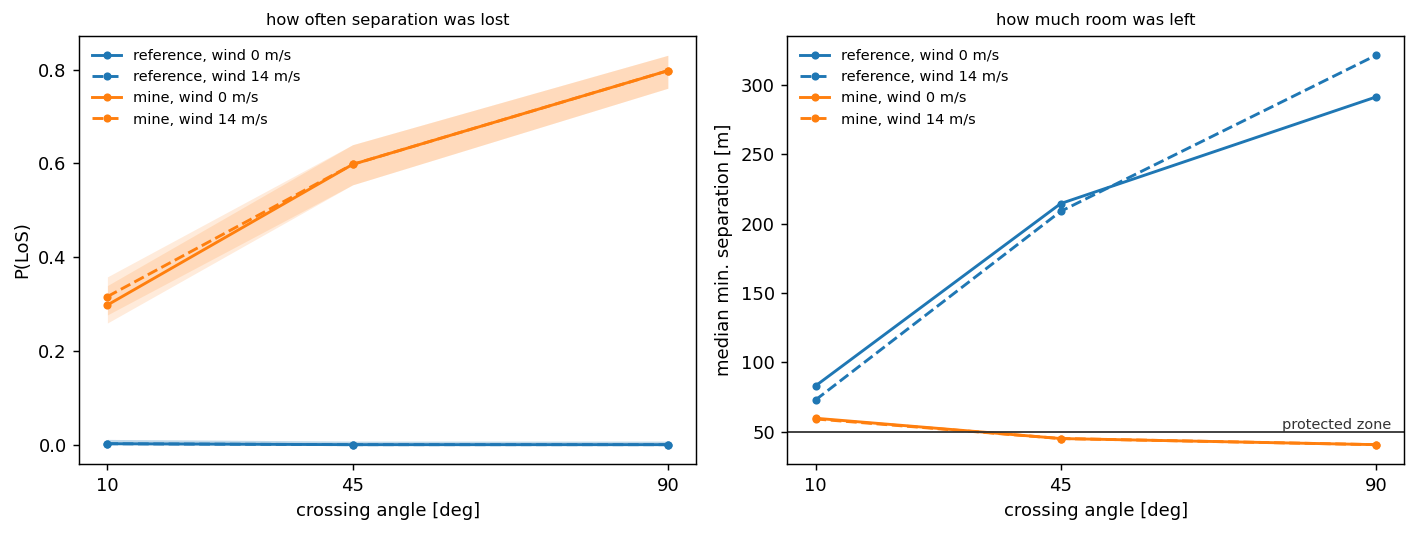

In [6]:
fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(11.0, 4.2))

for name, colour in (("reference", BLUE), ("mine", ORANGE)):
    for w, style in zip(WINDS, ("-", "--")):
        g = sorted((r for r in rows if r["stack"] == name and r["wind_ms"] == w),
                   key=lambda r: r["dpsi"])
        xs = [r["dpsi"] for r in g]
        ax_p.plot(xs, [r["p_los"] for r in g], style, marker="o", ms=3.5, lw=1.6, color=colour,
                  label=f"{name}, wind {w:.0f} m/s")
        ax_p.fill_between(xs, [r["p_los_lo"] for r in g], [r["p_los_hi"] for r in g],
                          alpha=0.15, color=colour, lw=0)
        ax_m.plot(xs, [r["median_min_sep"] for r in g], style, marker="o", ms=3.5, lw=1.6,
                  color=colour, label=f"{name}, wind {w:.0f} m/s")

ax_m.axhline(RPZ, color="0.2", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.2")
for ax, ylab, title in ((ax_p, "P(LoS)", "how often separation was lost"),
                        (ax_m, "median min. separation [m]", "how much room was left")):
    ax.set_xlabel("crossing angle [deg]")
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(ANGLES)
    ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()
publish(fig, "byo-full-stack")

## What came out

Every one of the nine objects above went through `run_experiment` untouched, and the runner needed
no knowledge that they were not library components. That is the point of the exercise. The numbers
are the by-product, but they are worth reading.

**The reference never loses separation** in any of the six cells. The custom stack loses it in
**30% to 80%** of encounters, and its median drops **below the protected zone** at 45° and 90° —
45.0 m and 40.6 m against a 50 m zone. The median encounter is a breach.

**Both stacks get easier or harder with angle, in opposite directions.** The reference improves as
the crossing widens (median 83 → 291 m); ours gets steadily worse (0.30 → 0.80). Wider crossings
are the easy end for a predictive detector and the hard end for a distance-triggered one, because
the same distance buys less and less time:

| crossing | closing speed | time from the 100 m trigger | time from the 70 m turn |
|---|---|---|---|
| 10° | 1.74 m/s | 57 s | 40 s |
| 45° | 7.65 m/s | 13 s | 9 s |
| 90° | 14.14 m/s | **7 s** | **5 s** |

Five seconds is not enough for a laggy rotorcraft to turn 90° and translate clear. `StateBased`
fires on `t_lookahead`, which is a time, so it is unaffected.

**The wind confirms the algebra above.** `LaggedRotor` responds to it only at 10° — 0.298 → 0.316,
median 59.68 → 59.16 — and is **bit-identical** at 45° and 90°. That is the linear cancellation
doing exactly what the derivation says: only the `v_max` clamp can break it, and the clamp only
fires where the airspeed demand is near the envelope. At 10° both aircraft fly nearly north and need
17.2 m/s of an 18 m/s envelope against the crosswind; at 45° and 90° the intruder's leg needs about
10 m/s and never saturates. `Multirotor` moves at every angle because it clamps its target rather
than its result.

**`detection_rate` separates the two designs in one column**: ~1.0 for ours at every cell, 0.44 to
0.74 for the reference. A predictive detector stops firing once resolution has opened the predicted
miss past `rpz`; a reactive one cannot, because it never predicted anything.

One honest limit: nine components changed at once. This is a demonstration that the seams compose,
not an attribution of the failure to any one of them.